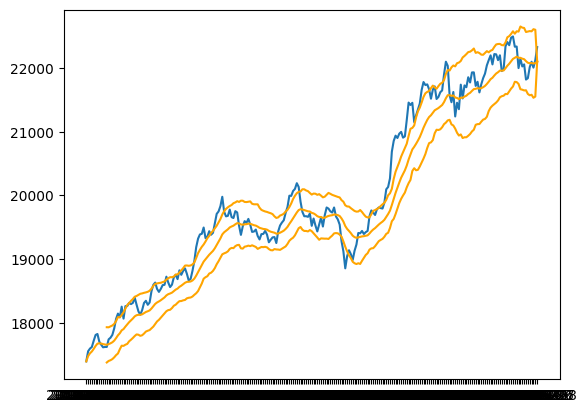

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



def atr(data,period):
    values=np.zeros(len(data))
#     data['atr']=[]
#     for k in range(0,14):
#         data['atr'].iloc[k]=0
    for i in range(1,len(data)-period-1):
        tr=np.zeros(period)
        for j in range(0,period):
            np1=np.array([(data['High'].iloc[i+j]-data['Low'].iloc[i+j]),abs(data['High'].iloc[i+j]-data['Close'].iloc[i+j-1]),abs(data['Low'].iloc[i+j]-data['Close'].iloc[i+j-1])])
            tr[j]=np.sort(np1)[-1]
        values[i+period]=(tr.sum())/period
        
    return(values)

            

def keltner_channel(data,ema_period,atr_period,multiplier):
    data['atr']=atr(data,atr_period)
    data['ema']=data['Close'].ewm(span=ema_period,adjust='false').mean()
    data['up']=data['ema']+multiplier*atr(data,atr_period)
    data['low']=data['ema']-multiplier*atr(data,atr_period)
    plt.plot(data['Date'],data["Close"])
    plt.plot(data["ema"],c='orange')
    plt.plot(data["up"].iloc[atr_period+1:],c='orange')
    plt.plot(data["low"].iloc[atr_period+1:],c='orange')
    plt.show()
    #print(data.head(20))
df=pd.read_csv('ndata.csv')
keltner_channel(df,20,10,2)
